In [ ]:
# Install packages
!pip install huggingface_hub
!pip install datasets
!pip install evaluate
#!pip install bert_score
!pip install rouge_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system ==

In [ ]:
# Import necessary modules
from torch import Tensor
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel
from datasets import load_dataset
from copy import deepcopy
from tqdm import tqdm
from peft import PeftModel, PeftConfig
import matplotlib.pyplot as plt
import torch.nn.functional as F
import evaluate
import torch
import re
plt.rcParams["font.family"] = "serif"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Use the token to log in
from huggingface_hub import login
login("") # Enter your hugging face token

In [ ]:
# Load Models

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
tokenizer.pad_token = tokenizer.eos_token

# Base Llama Model
base_model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B").to(device)

# Layerskip Model
# layerskip_tokenizer = AutoTokenizer.from_pretrained("facebook/layerskip-llama3.2-1B")
layerskip_model = AutoModelForCausalLM.from_pretrained("facebook/layerskip-llama3.2-1B").to(device)
layerskip_layers = layerskip_model.model.layers

# # Fine-tuned model
finetuned_model = AutoModelForCausalLM.from_pretrained("HassaanSeeker/llama-3.2-1b-guanco-finetuned-qlora-layerskip").to(device)
finetuned_base_model = AutoModelForCausalLM.from_pretrained("HassaanSeeker/llama-3.2-1b-guanco-finetuned").to(device)


In [ ]:
# Load ROUGE metric
rouge = evaluate.load("rouge")
#bert = evaluate.load("bertscore")
perplexity = evaluate.load("perplexity", module_type="metric")

In [ ]:
dataset = load_dataset("mlabonne/guanaco-llama2-1k")
train_dataset = dataset['train']
test_dataset = dataset['train']
#test_dataset = dataset['test']
#validation_dataset = dataset['validation']

README.md:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

(…)-00000-of-00001-9ad84bb9cf65a42f.parquet:   0%|          | 0.00/967k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
print(train_dataset[0]['text'])
print()
print(train_dataset[1]['text'])
print()
print(train_dataset[2]['text'])
print()
print(train_dataset[3]['text'])
print()
print(train_dataset[4]['text'])

<s>[INST] Me gradué hace poco de la carrera de medicina ¿Me podrías aconsejar para conseguir rápidamente un puesto de trabajo? [/INST] Esto vale tanto para médicos como para cualquier otra profesión tras finalizar los estudios aniversarios y mi consejo sería preguntar a cuántas personas haya conocido mejor. En este caso, mi primera opción sería hablar con otros profesionales médicos, echar currículos en hospitales y cualquier centro de salud. En paralelo, trabajaría por mejorar mi marca personal como médico mediante un blog o formas digitales de comunicación como los vídeos. Y, para mejorar las posibilidades de encontrar trabajo, también participaría en congresos y encuentros para conseguir más contactos. Y, además de todo lo anterior, seguiría estudiando para presentarme a las oposiciones y ejercer la medicina en el sector público de mi país. </s>

<s>[INST] Самый великий человек из всех живших на планете? [/INST] Для начала нужно выбрать критерии величия человека. Обычно великим назы

In [ ]:
def evaluate_next_token_predictions(text, model, tokenizer, max_len=128):
    tokens = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len)
    input_ids = tokens.input_ids.to(model.device)

    # Shift input to predict next token at each step
    logits = model(input_ids).logits  # shape: [1, seq_len, vocab_size]
    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]

    # Cross-entropy loss (avg over tokens)
    loss = F.cross_entropy(shift_logits.reshape(-1, shift_logits.size(-1)), shift_labels.reshape(-1), reduction="mean")

    # Token-wise prediction accuracy
    preds = shift_logits.argmax(dim=-1)
    accuracy = (preds == shift_labels).float().mean().item()

    return loss.item(), accuracy

In [ ]:
models = {"LLaMA 3.2 1B": base_model, "LayerSkip 3.2 1B": layerskip_model, "Finetuned LLaMA 3.2 1B": finetuned_base_model, "Finetuned LayerSkip 3.2 1B":finetuned_model}
# Store all results here
early_exit_metrics = {
    "LLaMA 3.2 1B": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "LayerSkip 3.2 1B": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "Finetuned LLaMA 3.2 1B": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "Finetuned LayerSkip 3.2 1B": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}")
    original_layers = model.model.layers  # Save full depth

    for i in range(len(original_layers)):
        model.model.layers = original_layers[:i + 1]  # Simulate early exit at i+1

        total_loss, total_acc, count = 0.0, 0.0, 0

        for example in test_dataset.select(range(1000)):
            text = example["text"].strip()
            if not text:
                continue
            try:
                loss, acc = evaluate_next_token_predictions(text, model, tokenizer)
                total_loss += loss
                total_acc += acc
                count += 1
            except Exception as e:
                print(f"[!] Skipping due to error: {e}")
                continue

        if count == 0:
            continue

        avg_loss = total_loss / count
        avg_ppl = torch.exp(torch.tensor(avg_loss)).item()
        avg_acc = total_acc / count

        # Store results
        early_exit_metrics[model_name]["layers"].append(i + 1)
        early_exit_metrics[model_name]["loss"].append(avg_loss)
        early_exit_metrics[model_name]["accuracy"].append(avg_acc)
        early_exit_metrics[model_name]["perplexity"].append(avg_ppl)

        print(f"[{model_name}] Layer {i+1} — Loss: {avg_loss:.4f}, PPL: {avg_ppl:.2f}, Acc: {avg_acc:.4f}")

    # Restore full layers after testing
    model.model.layers = original_layers


Evaluating LLaMA 3.2 1B
[LLaMA 3.2 1B] Layer 1 — Loss: 33.7650, PPL: 461255261290496.00, Acc: 0.0003
[LLaMA 3.2 1B] Layer 2 — Loss: 20.1971, PPL: 590882816.00, Acc: 0.0004
[LLaMA 3.2 1B] Layer 3 — Loss: 15.5882, PPL: 5886459.50, Acc: 0.0003
[LLaMA 3.2 1B] Layer 4 — Loss: 13.6638, PPL: 859231.44, Acc: 0.0004
[LLaMA 3.2 1B] Layer 5 — Loss: 12.8236, PPL: 370871.28, Acc: 0.0009
[LLaMA 3.2 1B] Layer 6 — Loss: 12.5689, PPL: 287474.56, Acc: 0.0017
[LLaMA 3.2 1B] Layer 7 — Loss: 12.7768, PPL: 353893.91, Acc: 0.0014
[LLaMA 3.2 1B] Layer 8 — Loss: 12.7859, PPL: 357140.62, Acc: 0.0019
[LLaMA 3.2 1B] Layer 9 — Loss: 12.5916, PPL: 294072.12, Acc: 0.0036
[LLaMA 3.2 1B] Layer 10 — Loss: 11.5759, PPL: 106505.27, Acc: 0.0119
[LLaMA 3.2 1B] Layer 11 — Loss: 10.4798, PPL: 35590.08, Acc: 0.0326
[LLaMA 3.2 1B] Layer 12 — Loss: 9.4664, PPL: 12917.99, Acc: 0.0642
[LLaMA 3.2 1B] Layer 13 — Loss: 7.9943, PPL: 2964.12, Acc: 0.1205
[LLaMA 3.2 1B] Layer 14 — Loss: 5.8889, PPL: 361.02, Acc: 0.2271
[LLaMA 3.2 1B] 

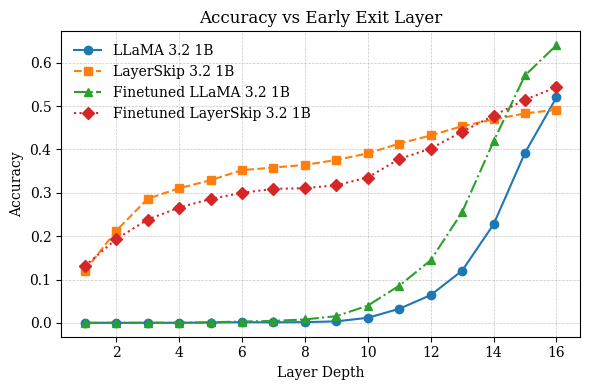

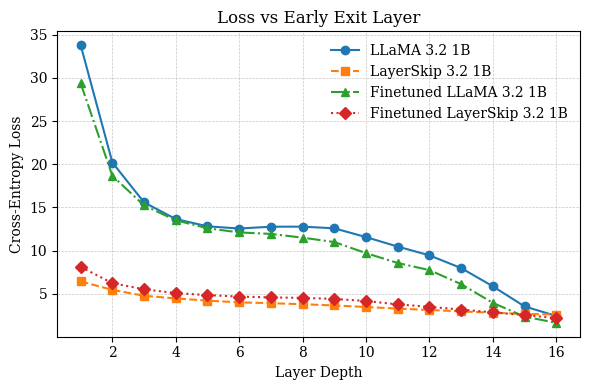

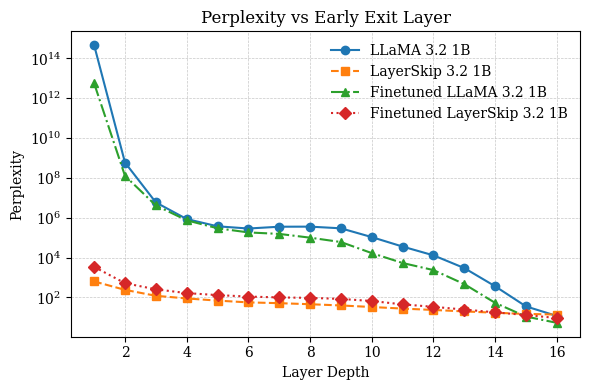

In [ ]:
def plot_metric(metric_name, ylabel):
    plt.figure(figsize=(6, 4), dpi=100)
    markers = ['o', 's', '^', 'D', '*', 'x']
    linestyles = ['-', '--', '-.', ':']

    for idx, model_name in enumerate(early_exit_metrics):
        plt.plot(early_exit_metrics[model_name]["layers"],
                 early_exit_metrics[model_name][metric_name],
                 marker=markers[idx % len(markers)],
                 linestyle=linestyles[idx % len(linestyles)],
                 label=model_name)

    plt.title(f"{metric_name.replace('_', ' ').title()} vs Early Exit Layer", fontname="serif")
    plt.xlabel("Layer Depth", fontname="serif")
    plt.ylabel(ylabel, fontname="serif")
    plt.xticks(fontname="serif")
    plt.yticks(fontname="serif")

    if metric_name == "perplexity":
        plt.yscale('log')  # ✨ Log scale for perplexity ✨

    plt.legend(loc='best', frameon=False)
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot all 3 metrics
plot_metric("accuracy", "Accuracy")
plot_metric("loss", "Cross-Entropy Loss")
plot_metric("perplexity", "Perplexity")

In [ ]:
models = {"LLaMA 3.2 1B": base_model, "LayerSkip 3.2 1B": layerskip_model, "Finetuned LLaMA 3.2 1B": finetuned_base_model, "Finetuned LayerSkip 3.2 1B":finetuned_model}
# Store all results here
skip_layer_metrics = {
    "LLaMA 3.2 1B": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "LayerSkip 3.2 1B": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "Finetuned LLaMA 3.2 1B": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
    "Finetuned LayerSkip 3.2 1B": {"layers": [], "loss": [], "accuracy": [], "perplexity": []},
}
for model_name, model in models.items():
    print(f"\nEvaluating {model_name}")
    original_layers = model.model.layers  # Save full depth

    for i in range(len(original_layers)):
        model.model.layers = original_layers[:i] + original_layers[i + 1:]  # Simulate early exit at i+1

        total_loss, total_acc, count = 0.0, 0.0, 0

        for example in test_dataset.select(range(1000)):
            text = example["text"].strip()
            if not text:
                continue
            try:
                loss, acc = evaluate_next_token_predictions(text, model, tokenizer)
                total_loss += loss
                total_acc += acc
                count += 1
            except Exception as e:
                print(f"[!] Skipping due to error: {e}")
                continue

        if count == 0:
            continue

        avg_loss = total_loss / count
        avg_ppl = torch.exp(torch.tensor(avg_loss)).item()
        avg_acc = total_acc / count

        # Store results
        skip_layer_metrics[model_name]["layers"].append(i + 1)
        skip_layer_metrics[model_name]["loss"].append(avg_loss)
        skip_layer_metrics[model_name]["accuracy"].append(avg_acc)
        skip_layer_metrics[model_name]["perplexity"].append(avg_ppl)

        print(f"[{model_name}] Layer {i+1} — Loss: {avg_loss:.4f}, PPL: {avg_ppl:.2f}, Acc: {avg_acc:.4f}")

    # Restore full layers after testing
    model.model.layers = original_layers


Evaluating LLaMA 3.2 1B
[LLaMA 3.2 1B] Layer 1 — Loss: 10.9181, PPL: 55166.38, Acc: 0.0072
[LLaMA 3.2 1B] Layer 2 — Loss: 8.0263, PPL: 3060.31, Acc: 0.0906
[LLaMA 3.2 1B] Layer 3 — Loss: 3.1857, PPL: 24.18, Acc: 0.4152
[LLaMA 3.2 1B] Layer 4 — Loss: 3.1330, PPL: 22.94, Acc: 0.4227
[LLaMA 3.2 1B] Layer 5 — Loss: 2.8333, PPL: 17.00, Acc: 0.4623
[LLaMA 3.2 1B] Layer 6 — Loss: 2.8494, PPL: 17.28, Acc: 0.4564
[LLaMA 3.2 1B] Layer 7 — Loss: 2.6656, PPL: 14.38, Acc: 0.4926
[LLaMA 3.2 1B] Layer 8 — Loss: 2.7924, PPL: 16.32, Acc: 0.4747
[LLaMA 3.2 1B] Layer 9 — Loss: 2.8189, PPL: 16.76, Acc: 0.4607
[LLaMA 3.2 1B] Layer 10 — Loss: 2.9928, PPL: 19.94, Acc: 0.4369
[LLaMA 3.2 1B] Layer 11 — Loss: 3.0797, PPL: 21.75, Acc: 0.4218
[LLaMA 3.2 1B] Layer 12 — Loss: 3.2627, PPL: 26.12, Acc: 0.3876
[LLaMA 3.2 1B] Layer 13 — Loss: 2.8762, PPL: 17.75, Acc: 0.4432
[LLaMA 3.2 1B] Layer 14 — Loss: 3.1423, PPL: 23.16, Acc: 0.4097
[LLaMA 3.2 1B] Layer 15 — Loss: 3.3040, PPL: 27.22, Acc: 0.3979
[LLaMA 3.2 1B] Lay

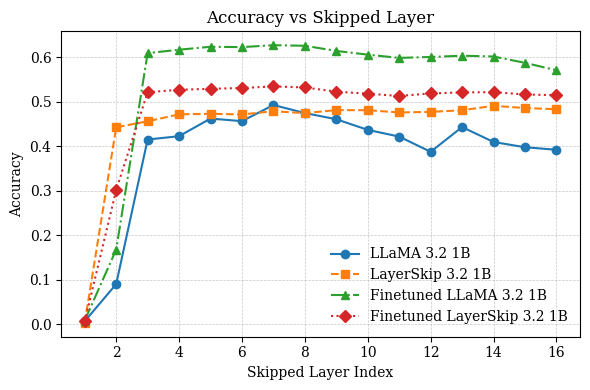

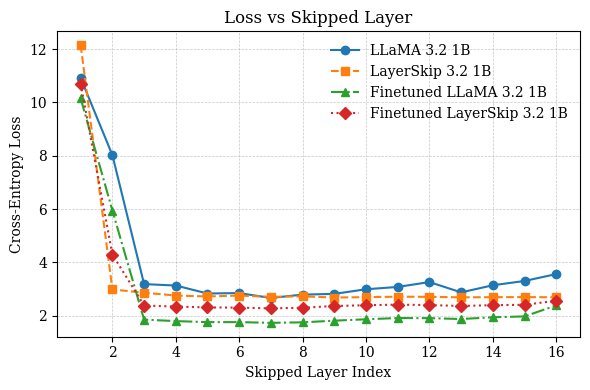

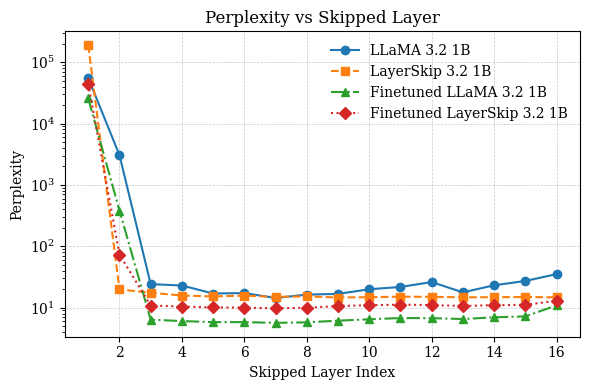

In [ ]:
def plot_metric(metric_name, ylabel):
    plt.figure(figsize=(6, 4), dpi=100)
    markers = ['o', 's', '^', 'D', '*', 'x']
    linestyles = ['-', '--', '-.', ':']

    for idx, model_name in enumerate(skip_layer_metrics):
        plt.plot(skip_layer_metrics[model_name]["layers"],
                 skip_layer_metrics[model_name][metric_name],
                 marker=markers[idx % len(markers)],
                 linestyle=linestyles[idx % len(linestyles)],
                 label=model_name)

    plt.title(f"{metric_name.replace('_', ' ').title()} vs Skipped Layer", fontname="serif")
    plt.xlabel("Skipped Layer Index", fontname="serif")
    plt.ylabel(ylabel, fontname="serif")
    plt.xticks(fontname="serif")
    plt.yticks(fontname="serif")

    if metric_name == "perplexity":
        plt.yscale('log')  # ✨ Log scale for perplexity ✨

    plt.legend(loc='best', frameon=False)
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot all 3 metrics
plot_metric("accuracy", "Accuracy")
plot_metric("loss", "Cross-Entropy Loss")
plot_metric("perplexity", "Perplexity")